<a href="https://colab.research.google.com/github/smcgovern-proj/neuromatch_ecog_project/blob/main/log_reg_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [131]:
# @title Configure

# Window preset per Kai Miller's paper
start_offset = -199
end_offset = 400

# Filtering
bandpass = [70, 150] #will need to check if oscillations are true
fs = 1000

# Subject specific config
electrode_dict = {
    '0': [11, 35],
    '1': [43, 46], # No key_press time
    '2': [35, 7],  # No key_press time
    '3': [15, 17],
    '4': [23, 24],
    '5': [25, 27],
    '6': False     # Repeated data
}

# Remember total n. of samples should be 15x higher than the features
window_dict = {
    '0': {'win_length': 60, 'step': 40},
    '1': {'win_length': 60, 'step': 40},
    '2': {'win_length': 60, 'step': 40},
    '3': {'win_length': 60, 'step': 40},
    '4': {'win_length': 60, 'step': 40},
    '5': {'win_length': 60, 'step': 40},
    '6': False
}

# General functions

In [113]:
# @title Data retrieval
import os, requests

fname = 'faceshouses.npz'
url = "https://osf.io/argh7/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [114]:
# @title Imports and plot settings

import numpy as np
from matplotlib import rcParams
from matplotlib import pyplot as plt
from scipy import signal
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

In [115]:
# @title Data loading

alldat = np.load(fname, allow_pickle=True)['dat']

In [116]:
# @title Auxiliary functions

def get_epoch(V, t_on, start_offset, end_offset):
  '''
  Get same epoch across all trials

  Args:
    V: float32 np.array (samples, electrodes)
    t_on: np.array (trials)
    start_offset: int
    end_offset: int

  Return:
    epochs: np.array (trials, samples, electrodes)
  '''

  # Epoch
  epochs_list = []

  for on_time in t_on:
      start = on_time + start_offset
      end = on_time + end_offset

      # Window
      trial_window = V[start:end]
      epochs_list.append(trial_window)

  # Convert no np.array
  epochs = np.array(epochs_list)

  return epochs

def get_power(V):
  '''
  Get broadband power for voltage

  Args:
    V: float32 np.array (samples, electrodes)

  Return:
    power: power same range as V
  '''

  b, a = signal.butter(3, [50], btype='high', fs=1000)
  V = signal.filtfilt(b, a, V, 0)

  V = np.abs(V)**2

  b, a = signal.butter(3, [10], btype='low', fs=1000)
  V = signal.filtfilt(b, a, V, 0)

  V = V/V.mean(0)

  return V

def get_time_bins(epochs, win_length, step):
    """
    Break epochs into overlapping time bins and compute envelope statistics.

    Args:
        epochs: np.array, shape (n_epochs, samples, electrodes)
        win_length: int, window length in samples
        step: int, window step in samples

    Returns:
        tuple of (means, variances), both shape (n_epochs, n_windows, n_electrodes)
    """
    n_epochs, epoch_length, n_electrodes = epochs.shape
    n_windows = (epoch_length - win_length) // step + 1

    # Pre-allocate output arrays
    means = np.zeros((n_epochs, n_windows, n_electrodes))
    variances = np.zeros((n_epochs, n_windows, n_electrodes))

    # Process all epochs
    for trial_idx, epoch in enumerate(epochs):
        envelope = get_power(epoch)  # Shape: (samples, electrodes)

        # Extract windows explicitly (clear and correct)
        for win_idx in range(n_windows):
            start = win_idx * step
            end = start + win_length
            window = envelope[start:end, :]  # Shape: (win_length, n_electrodes)

            means[trial_idx, win_idx, :] = np.mean(window, axis=0)
            variances[trial_idx, win_idx, :] = np.var(window, axis=0)

    return means, variances

def get_pressed(t_on, t_off, key_press):
    '''
    Check wether button was pressed on trial

    args:
        t_on: np.array (trials)
        t_off: np.array (trials)
        key_press: np.array (trials)
    returns:
        label: np.array (trials)
    '''
    t_on = np.asarray(t_on)
    t_off = np.asarray(t_off)
    key_press = np.asarray(key_press)

    # keep only aligned trials
    n = min(len(t_on), len(t_off))
    t_on = t_on[:n]
    t_off = t_off[:n]

    label = []
    for i in range(n):
        pressed = np.any((key_press >= t_on[i]) & (key_press < t_off[i]))
        label.append('face' if pressed else 'house')

    return label

# Clean data pipeline

In [132]:
'''
Get data per subject
'''

clean_data_sub = {}

for idx, subject in enumerate(alldat):
    if not electrode_dict.get(str(idx), False):
        continue

    dat = subject[0]

    # Data epochs
    V = dat['V'].astype('float32')
    epochs = get_epoch(V, dat['t_on'], start_offset, end_offset)

    # Window config
    win_length = window_dict[str(idx)]['win_length']
    step = window_dict[str(idx)]['step']
    means, variances = get_time_bins(epochs, win_length, step)

    # Select electrodes and build features
    sel = electrode_dict[str(idx)]
    means = means[:, :, sel]
    X = means.reshape(means.shape[0], -1)

    # Build labels
    stim = np.asarray(dat['stim_id'])
    labels = np.where(stim <= 50, 'house', 'face')

    clean_data_sub[idx] = {"X": X, "labels": labels}
    print(f'Done: {idx}')

Done: 0
Done: 1
Done: 2
Done: 3
Done: 4
Done: 5


In [133]:
'''Model training'''

for idx, sub_data in clean_data_sub.items():
    X_sub = sub_data["X"]
    y_sub = sub_data["labels"]

    # 10-fold CV accuracy scores on the sub's data
    cv_scores = cross_val_score(
        LogisticRegression(max_iter=5000),
        X_sub, y_sub,
        cv=10
    )

    sub_data["accuracies"] = cv_scores  # array of length 10

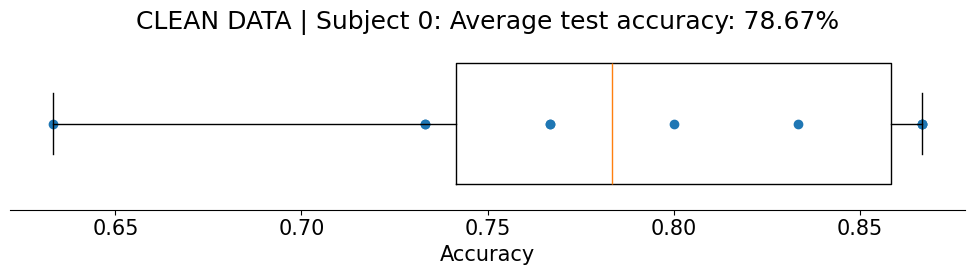

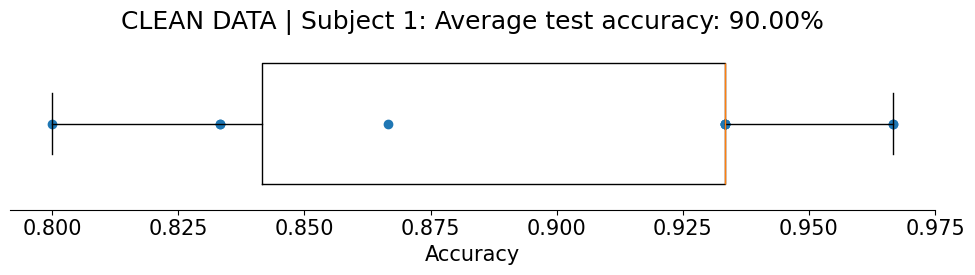

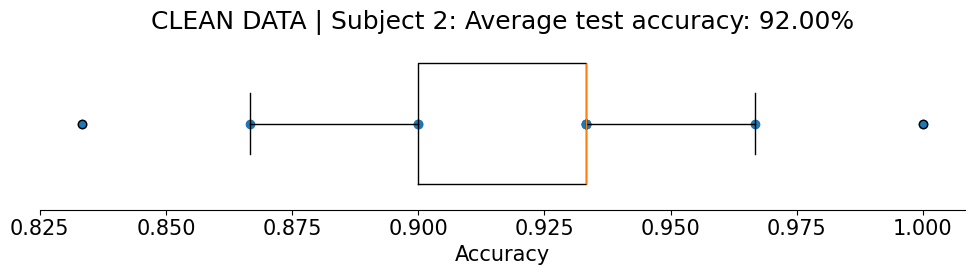

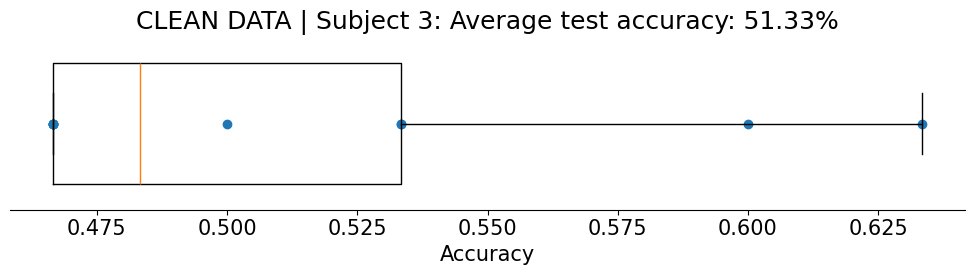

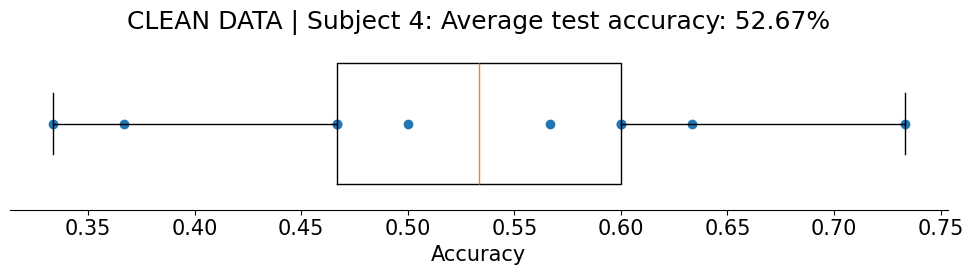

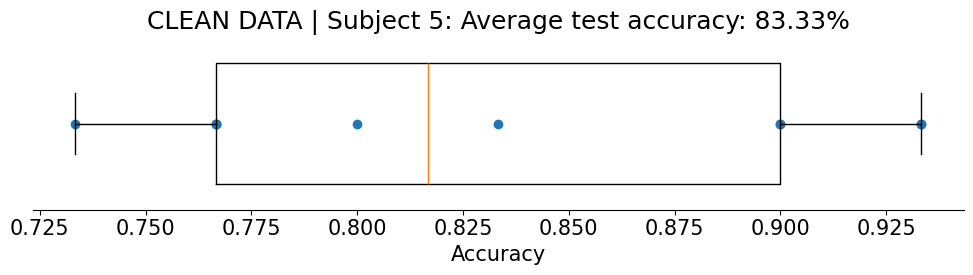

In [134]:
'''Acc plot'''

for idx, sub_data in clean_data_sub.items():
    accuracies = sub_data["accuracies"]
    y_sub = sub_data["labels"]

    f, ax = plt.subplots(figsize=(len(accuracies), 3))
    ax.boxplot(accuracies, vert=False, widths=.7)
    ax.scatter(accuracies, np.ones(len(accuracies)))
    ax.set(
      xlabel="Accuracy",
      yticks=[],
      title=f"CLEAN DATA | Subject {idx}: Average test accuracy: {accuracies.mean():.2%}"
    )
    ax.spines["left"].set_visible(False)
    plt.show()

# Noisy data pipeline

In [135]:
'''
Get data per subject
'''

noisy_data_sub = {}
for idx, subject in enumerate(alldat):
    if not electrode_dict.get(str(idx), False):
        continue

    dat = subject[1]

    # Data epochs
    V = dat['V'].astype('float32')
    epochs = get_epoch(V, dat['t_on'], start_offset, end_offset)

    # Window config
    win_length = window_dict[str(idx)]['win_length']
    step = window_dict[str(idx)]['step']
    means, variances = get_time_bins(epochs, win_length, step)

    sel = electrode_dict[str(idx)]
    means = means[:, :, sel]
    flat_means = means.reshape(means.shape[0], -1)

    # Set label types
    stim_labels = dat['stim_cat']
    pressed_labels = get_pressed(dat['t_on'], dat['t_off'], dat['key_press'])

    # Noise per trial as 1D scalars
    noise_list = np.asarray(dat['stim_noise']).squeeze().reshape(-1)

    noise_levels = {}

    # Separate per noise
    for idxx, flat_mean in enumerate(flat_means):
        noise = noise_list[idxx]
        key = str(noise)

        # Check if noise bin already exists
        if key not in noise_levels:
            noise_levels[key] = {'X': [], 'pressed_labels': [],'stim_labels': []}

        noise_levels[key]['X'].append(flat_mean)

        # Set data for button_pressed analysis
        noise_levels[key]['pressed_labels'].append(pressed_labels[idxx])

        # Set data for STIM CAT analysis
        if stim_labels[idxx] == 1:
            noise_levels[key]['stim_labels'].append('house')
        else:
            noise_levels[key]['stim_labels'].append('face')

    noisy_data_sub[str(idx)] = noise_levels
    print(f'Done: {idx}')


Done: 0
Done: 1
Done: 2
Done: 3
Done: 4
Done: 5


In [136]:
'''
Model training
'''
# from sklearn.model_selection import KFold

model = LogisticRegression(max_iter=5000)
# kf = KFold(n_splits=10, shuffle=True, random_state=42)

for idx, subj in noisy_data_sub.items():
    clean_sub = clean_data_sub[int(idx)]

    X_clean = clean_sub["X"]
    y_clean = clean_sub["labels"]

    model.fit(X_clean, y_clean)  # fit once per subject (not per noisy fold)

    for noise_level, sub_data in subj.items():
        X_noise_sub = np.asarray(sub_data["X"])

        # Prediction for STIMULUS CAT
        y_noise_sub = np.asarray(sub_data["stim_labels"])

        y_predoct = model.predict(X_noise_sub)
        noisy_fold_acc = accuracy_score(y_noise_sub, y_predoct)

        sub_data["stim_accuracies"] = np.array(noisy_fold_acc)

        # Prediction for BUTTON PRESSED
        y_noise_sub = np.asarray(sub_data["pressed_labels"])

        y_predoct = model.predict(X_noise_sub)
        noisy_fold_acc = accuracy_score(y_noise_sub, y_predoct)

        sub_data["pressed_accuracies"] = np.array(noisy_fold_acc)


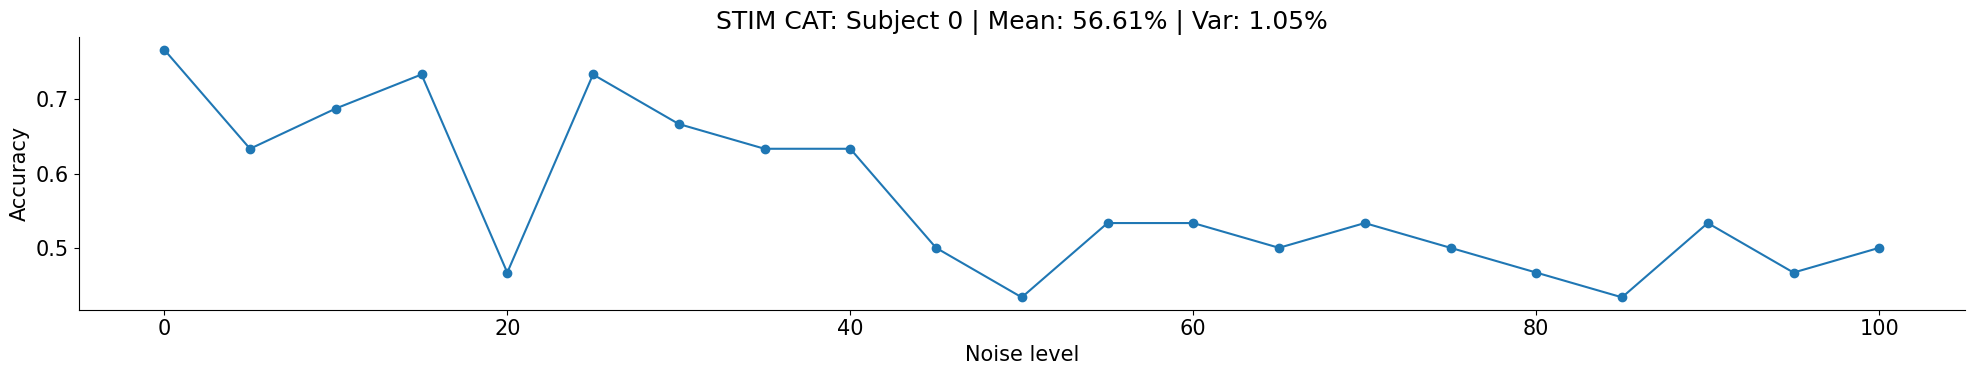

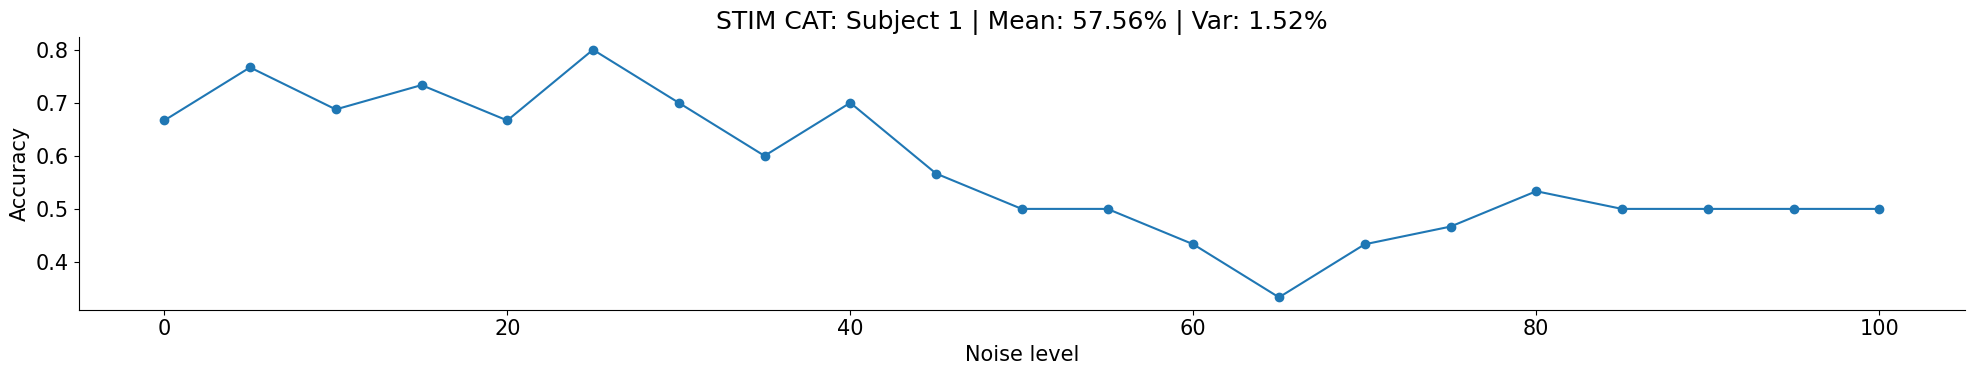

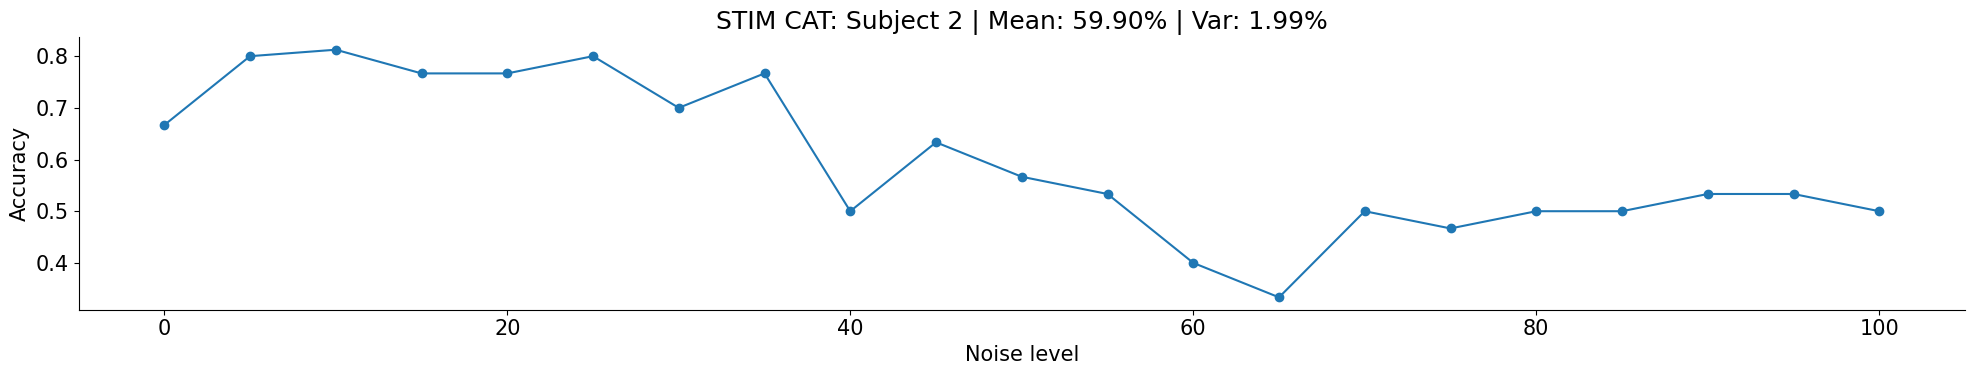

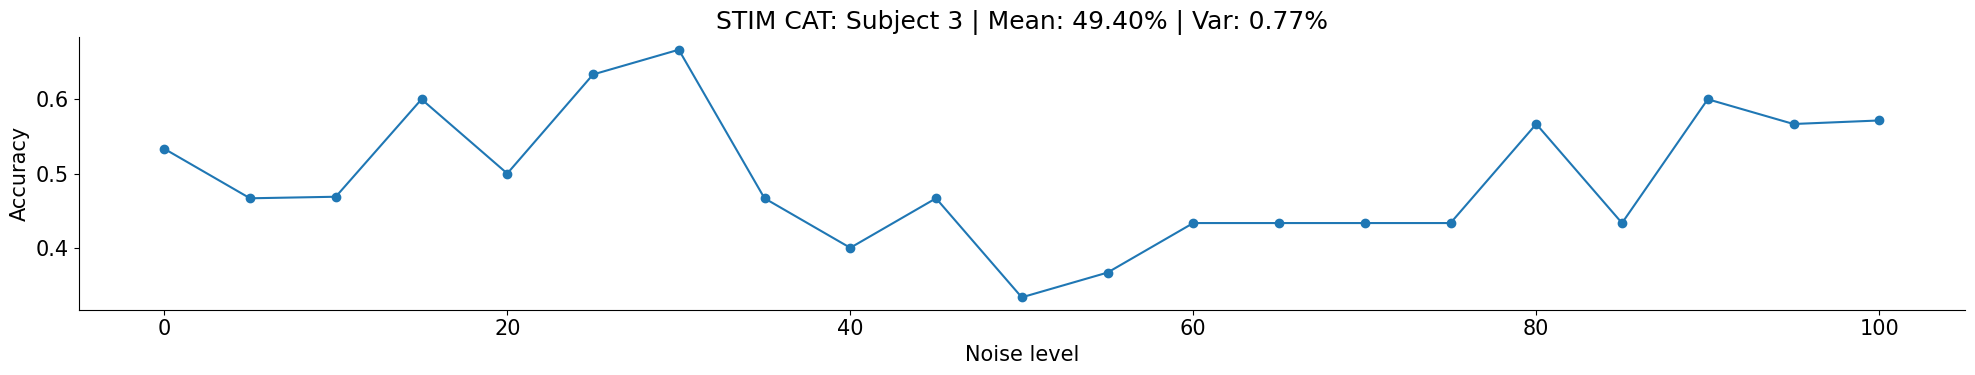

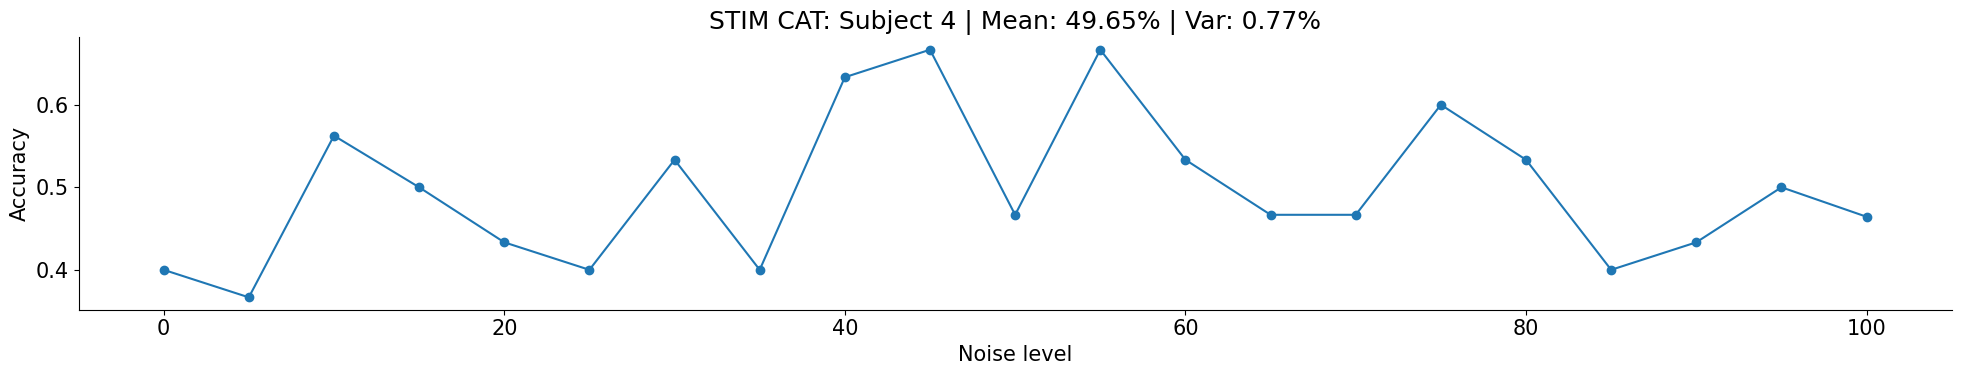

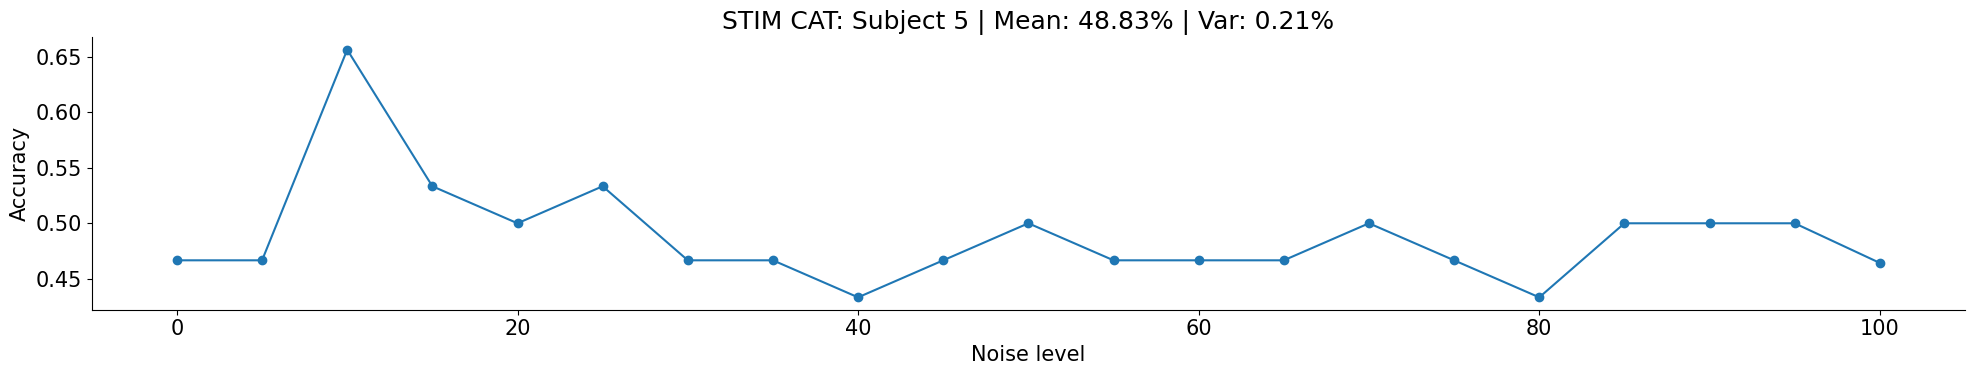

In [137]:
'''
STIMULUS CATEGORY Acc plots
'''

for subj_key, subj_dict in noisy_data_sub.items():
    noise_vals = np.array([float(k) for k in subj_dict.keys()])
    order = np.argsort(noise_vals)
    x = noise_vals[order]

    y = []
    for k in x:
        y.append(subj_dict[str(int(k) if k.is_integer() else k)]["stim_accuracies"].mean())

    y_mean = np.mean(y)
    y_var = np.var(y)

    fig, ax = plt.subplots()
    ax.plot(x, y, marker='o')
    ax.set(xlabel="Noise level", ylabel="Accuracy", title=f"STIM CAT: Subject {subj_key} | Mean: {y_mean:.2%} | Var: {y_var:.2%}")
    plt.show()


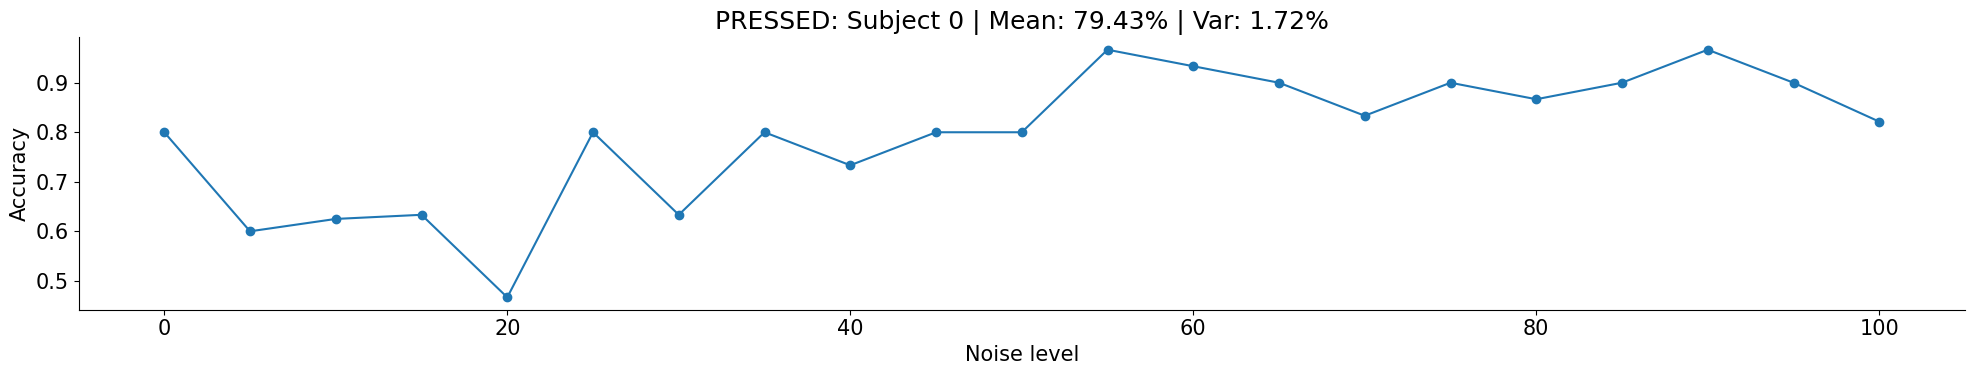

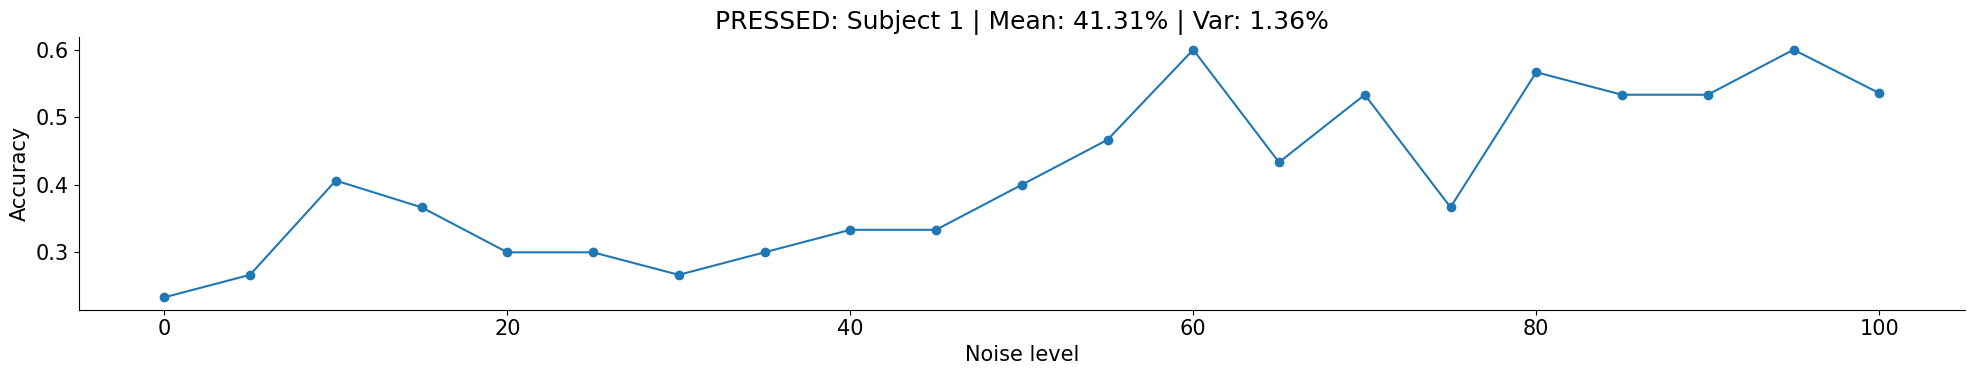

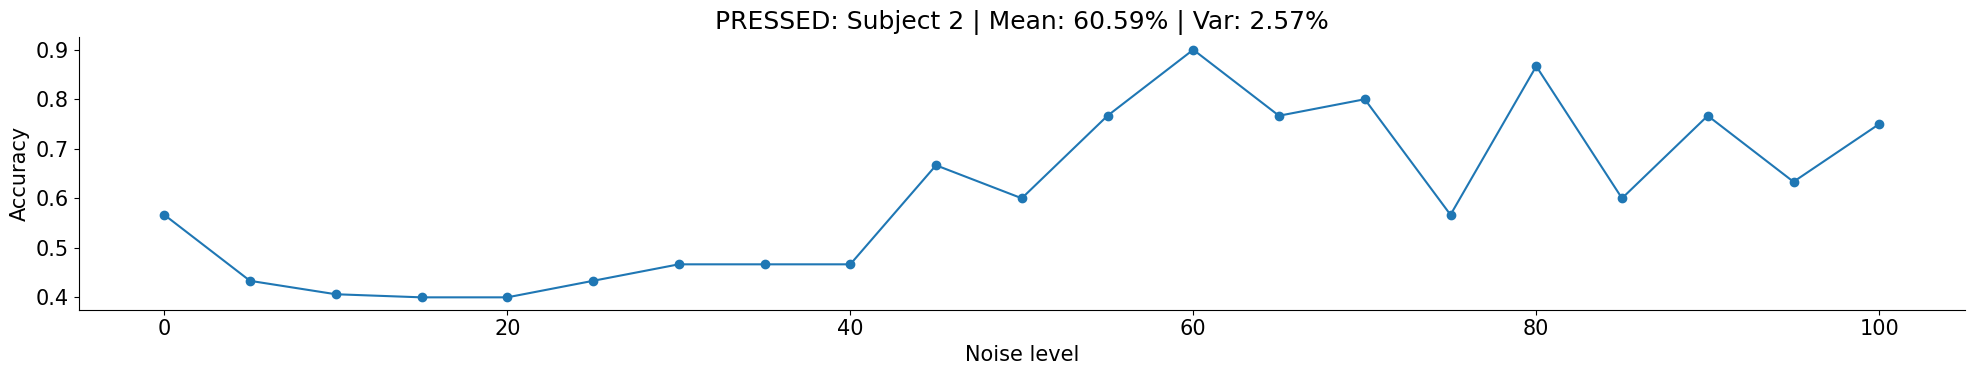

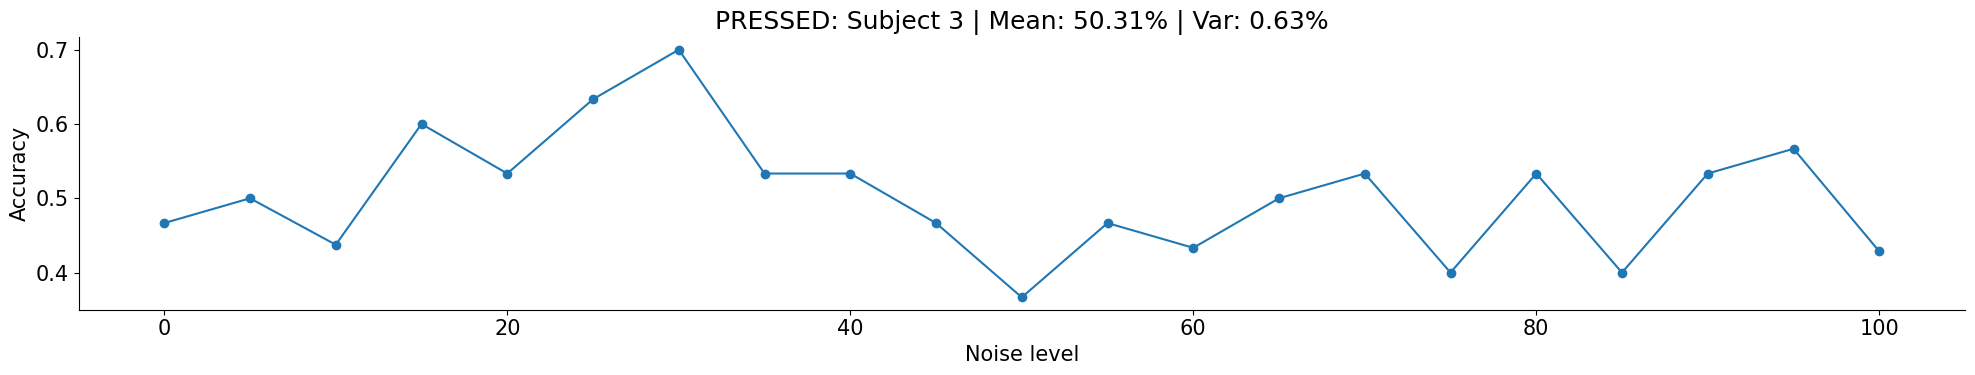

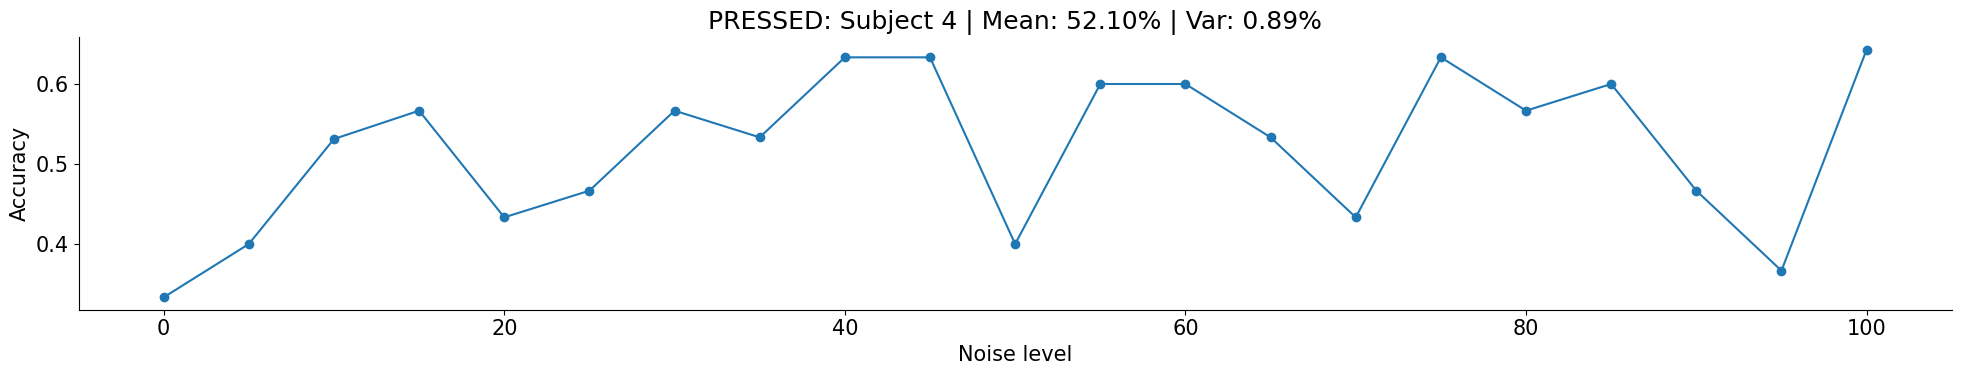

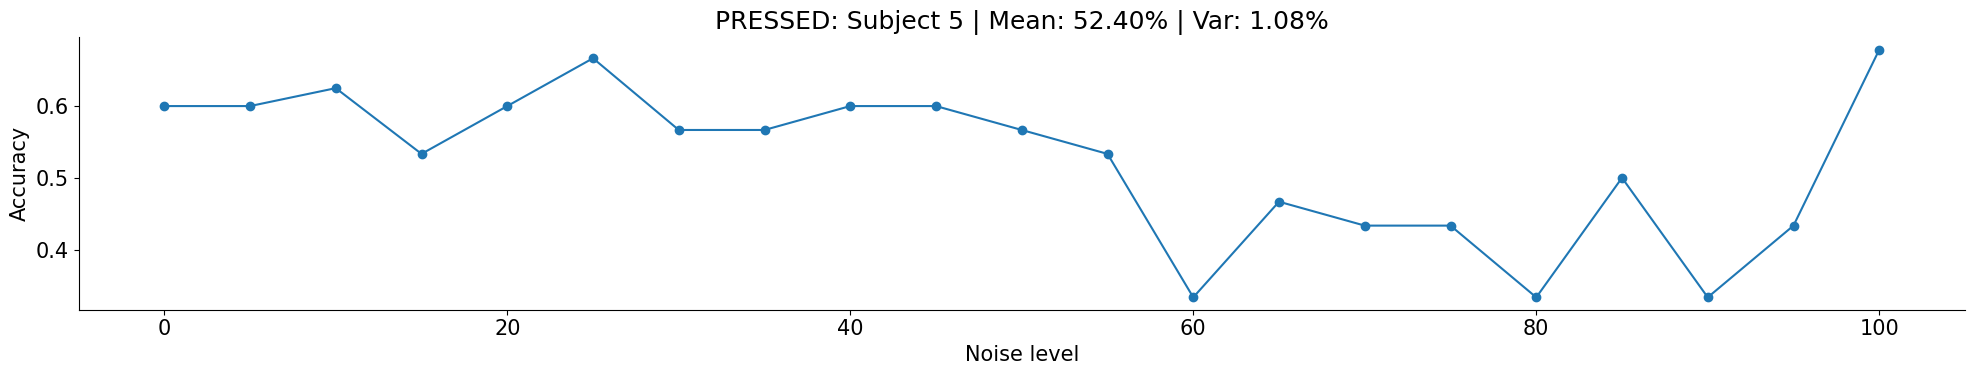

In [123]:
'''
BUTTON PRESSED Acc plots
'''

for subj_key, subj_dict in noisy_data_sub.items():
    noise_vals = np.array([float(k) for k in subj_dict.keys()])
    order = np.argsort(noise_vals)
    x = noise_vals[order]

    y = []
    for k in x:
        y.append(subj_dict[str(int(k) if k.is_integer() else k)]["pressed_accuracies"].mean())

    y_mean = np.mean(y)
    y_var = np.var(y)

    fig, ax = plt.subplots()
    ax.plot(x, y, marker='o')
    ax.set(xlabel="Noise level", ylabel="Accuracy", title=f"PRESSED: Subject {subj_key} | Mean: {y_mean:.2%} | Var: {y_var:.2%}")
    plt.show()
